In [3]:
#1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt









In [5]:
# Load Dataset
titanic = pd.read_csv('/content/Titanic-Dataset.csv')


In [11]:
# Display Data
print(titanic.head(10))
print(titanic.tail(10))
print(titanic.info())
print(titanic.describe())
print(titanic.isnull().sum())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex        Age  \
0                            Braund, Mr. Owen Harris    male  22.000000   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                             Heikkinen, Miss. Laina  female  26.000000   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                           Allen, Mr. William Henry    male  35.000000   
5                                   Moran, Mr. James    male  29.699118   
6                            McCarthy, Mr. Timothy J    male  54.000000   
7  

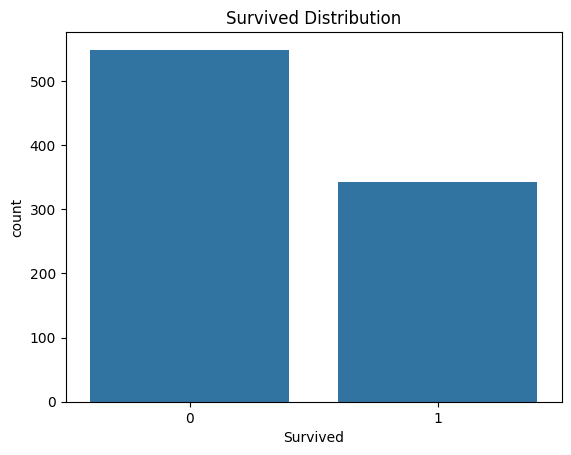

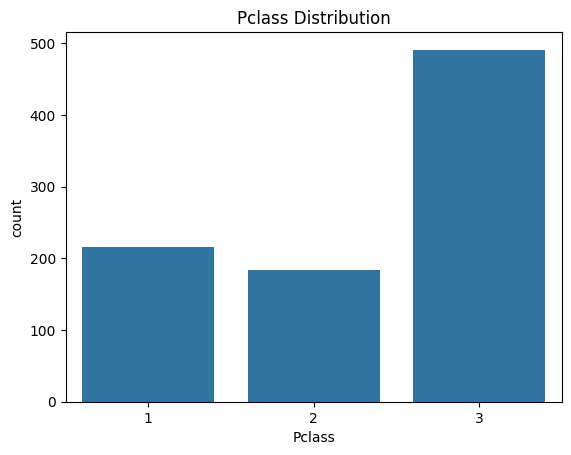

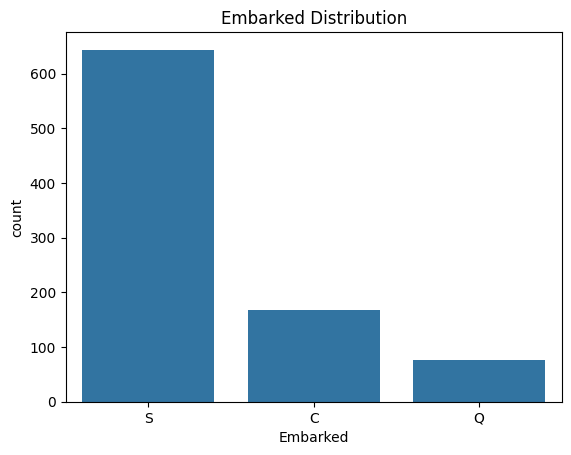

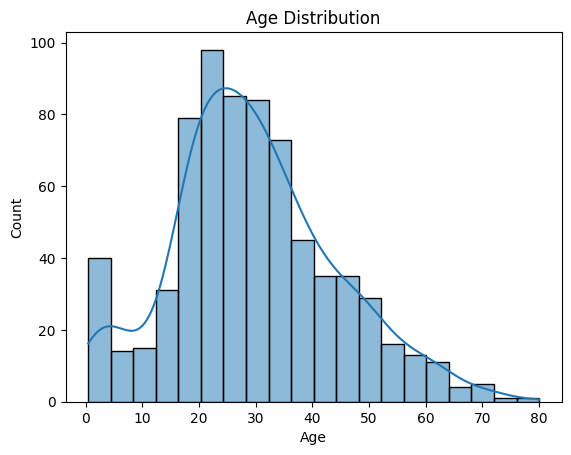

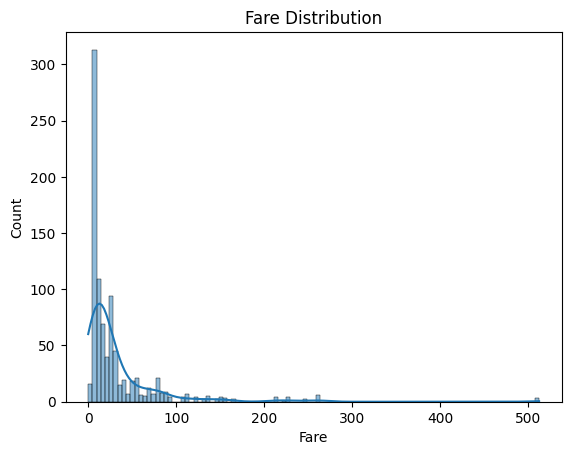

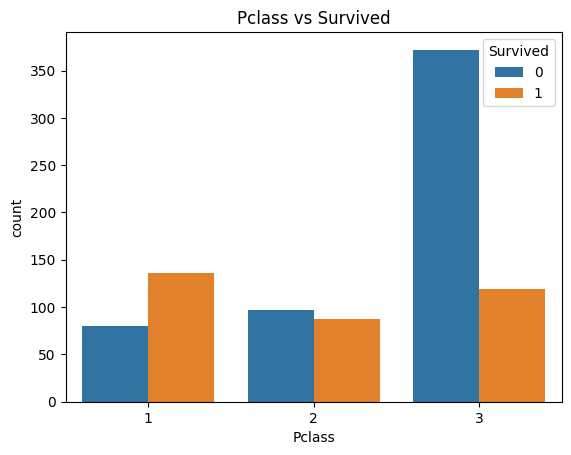

In [8]:
# ------------------ EDA ------------------

sns.countplot(data=titanic, x='Survived')
plt.title('Survived Distribution')
plt.show()

sns.countplot(data=titanic, x='Pclass')
plt.title('Pclass Distribution')
plt.show()

sns.countplot(data=titanic, x='Embarked')
plt.title('Embarked Distribution')
plt.show()

sns.histplot(data=titanic, x='Age', kde=True)
plt.title('Age Distribution')
plt.show()

sns.histplot(data=titanic, x='Fare', kde=True)
plt.title('Fare Distribution')
plt.show()

sns.countplot(data=titanic, x='Pclass', hue='Survived')
plt.title('Pclass vs Survived')
plt.show()



In [9]:
# ------------------ Data Preprocessing ------------------

# Fill missing values
titanic['Age'].fillna(titanic['Age'].mean(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

# Select required columns
data = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

# Convert text into numbers
data['Sex'] = data['Sex'].map({'male':0, 'female':1})
data['Embarked'] = data['Embarked'].map({'S':0, 'C':1, 'Q':2})


/tmp/ipykernel_679/3953947343.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].mean(), inplace=True)
/tmp/ipykernel_679/3953947343.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [10]:

# ------------------ Model Building ------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7932960893854749
